# Min-sum message passing on 1-character captchas

This notebook runs `numpyro.contrib.fwl` -- the fork's Find/Weigh/Learn procedure, whose
Find stage is the min-sum / max-product message-passing inference -- on
`PoissonMarkedPlacements` (`+experiment=poisson_captcha`), the Gamma/Dirichlet placement
model without relaxations.

The three stages, from `find_weigh_learn`:

1. **Find**: locate `K` modes of the unnormalized joint. Enumerable discrete latents are
   eliminated exactly by max-product message passing; continuous ones go to an `optimistix`
   minimiser, either as a single joint solve (`elimination="joint"`) or clique by clique
   over the junction tree with each factor-to-separator message an inner solve
   (`elimination="nested"` -- the min-sum pass).
2. **Weigh**: wrap each mode in a Gaussian whose covariance is the damped local empirical
   Fisher, mixed uniformly.
3. **Learn**: expose `log_weights`, `elbo` and `iwae` as differentiable functions of the
   parameters, so `log Z(theta)` can be optimized.

Unlike `captcha1-marionette.ipynb` this loads no checkpoint -- Find does its own MAP
inference from the prior, and stage 3 learns `log_scale` and `count_concentration` itself.

**Read the three findings below before trusting any number here.** In short: min-sum has no
messages to pass on this model (one clique); the configured MAP is unbounded, so
mode-finding only behaves under-converged; and the 2365-dimensional `z_where` simplex
straddles the float32 boundary, which puts `-inf` in some importance weights.

In [1]:
%cd ..

/home/eli/jupyterlab/captcha-numpyro


In [2]:
import os
import time

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import optimistix as optx
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

from numpyro import handlers
from numpyro.contrib.fwl import analyze, build_clique_tree, find_weigh_learn
from numpyro.infer.initialization import init_to_uniform

In [3]:
CONFIG_DIR = os.path.abspath("configs")
BATCH = 4


def build(*overrides):
    "Instantiate the poisson_captcha model and one test batch."
    with hydra.initialize_config_dir(version_base="1.3", config_dir=CONFIG_DIR,
                                     job_name="minsum"):
        cfg = hydra.compose(
            config_name="eval.yaml",
            overrides=["+experiment=poisson_captcha", f"data.batch_size={BATCH}",
                       *overrides],
        )
    datamodule = hydra.utils.instantiate(cfg.data)
    model = hydra.utils.instantiate(cfg.model)
    for batch in datamodule.test_dataloader():
        return model, jnp.asarray(batch[0])[:BATCH]


model, images = build()
images.shape

(4, 80, 80, 3)

## What the procedure sees

`analyze` classifies the sites; `build_clique_tree` builds the junction tree that min-sum
would pass its messages over.

In [4]:
structure = analyze(model, jax.random.key(0), (images,))
print(structure.summary())
print()
print(build_clique_tree(structure).summary())

continuous latents: ['color', 'z_rate', 'z_where', 'z_mark'] (packed dim 340572)
discrete latents:   [] (eliminated by max-product)
observed:           ['obs']
max_plate_nesting:  1
  color: markov blanket ['color', 'obs', 'z_mark', 'z_rate', 'z_where']
  z_rate: markov blanket ['obs', 'z_mark', 'z_rate', 'z_where']
  z_where: markov blanket ['obs', 'z_mark', 'z_where']
  z_mark: markov blanket ['obs', 'z_mark']

1 cliques, height 0, root 0
  clique 0: ['color', 'z_mark', 'z_rate', 'z_where'] | separator [] | interior ['color', 'z_mark', 'z_rate', 'z_where'] | factors ['color', 'obs', 'z_mark', 'z_rate', 'z_where']


### Finding 1: min-sum has nothing to eliminate on this model

Two things above matter.

**No discrete latents.** `PoissonMarkedPlacements` never samples discrete firing --
`z_rate` is Gamma, `z_where` and `z_mark` are Dirichlet, `color` is Beta -- so the
max-product half of Find never runs. That is deliberate (the class docstring notes the
pixelwise mixture is the exact marginalization of the marked process), but it means the
message passing here is entirely the continuous min-sum pass.

**One clique.** The junction tree is a single clique holding every latent, height 0. This is
structural, not an artifact of the parameterization: the whole image is one `obs` sample
site, so that factor's scope is `{color, z_rate, z_where, z_mark}`, and moralizing it
connects every latent to every other. With one clique there are no separators and no
messages, so `elimination="nested"` degenerates to a single joint solve over all 340k
coordinates -- verified two cells down.

In [5]:
SOLVER = dict(
    # Finding 2: init_to_sample draws land on the simplex boundary, where the unconstrained
    # initialization is already -inf, and Weigh then builds an invalid proposal.
    init_strategy=init_to_uniform,
    # Finding 2 again: this solve is deliberately loose. Converging it walks the latents
    # into the Dirichlet boundary singularity and makes every mode unusable.
    solver=optx.LBFGS(rtol=1e-4, atol=1e-4),
    max_solver_steps=128,
    covariance="diagonal",   # 85k coordinates per image: a dense Fisher will not fit
    num_particles=8,
)

t0 = time.time()
result = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4,
                          elimination="joint", **SOLVER)
print(f"Find/Weigh/Learn: {time.time() - t0:.1f}s over "
      f"{result.structure.packing.dim} continuous coordinates")
print("log_joint", np.asarray(result.log_joint).round(1))
print("converged", np.asarray(result.converged), "sweeps", np.asarray(result.sweeps))
print("params   ", {k: np.shape(v) for k, v in result.params.items()
                    if not isinstance(v, dict)})

/tmp/ipykernel_184651/2094872867.py:14: UserWarning: Out-of-support values provided to log prob method. The value argument should be within the support.
  result = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4,


Find/Weigh/Learn: 55.7s over 340572 continuous coordinates
log_joint [-424217.6      -inf -424311.8      -inf]
converged [False False False False] sweeps [1 1 1 1]
params    {'log_scale': (1,), 'count_concentration': (), '_fwl_loc': (4, 340572), '_fwl_scale': (4, 340572)}


In [6]:
t0 = time.time()
nested = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4,
                          elimination="nested", **SOLVER)
print(f"nested (min-sum): {time.time() - t0:.1f}s")
print("joint  log_joint", np.asarray(result.log_joint).round(1))
print("nested log_joint", np.asarray(nested.log_joint).round(1))
print("bit-identical:", bool(jnp.array_equal(result.log_joint, nested.log_joint)))

/tmp/ipykernel_184651/2040280225.py:2: UserWarning: Out-of-support values provided to log prob method. The value argument should be within the support.
  nested = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4,


nested (min-sum): 17.9s
joint  log_joint [-424217.6      -inf -424311.8      -inf]
nested log_joint [-424217.6      -inf -424311.8      -inf]
bit-identical: True


### Finding 2: at the configured concentrations the MAP is unbounded

`configs/model/poisson_captcha.yaml` sets `where_concentration=0.1` and
`mark_concentration=0.5`. A Dirichlet with concentration below 1 has a density that
diverges as any component approaches zero, so `log gamma_theta` is *unbounded above* on the
simplex boundary and no interior mode exists. Mode-finding does not converge to a posterior
mode; it walks toward the boundary until a constrained coordinate underflows to exactly 0
in float32 and falls off the support. Symptoms, all visible in this notebook:

* `-inf` entries in `log_joint` above, with out-of-support warnings from `log_prob`.
* An infinite entry in that mode's empirical Fisher, so
  `proposal_scale = sqrt(1 / (F + lambda))` returns **0**, and the mixture component is an
  invalid `Normal`. `find_weigh_learn` itself does not raise -- the zero is baked into
  `_fwl_scale` and the `ValueError` only surfaces on the first call to `guide`,
  `log_weights`, `elbo` or `iwae`. Worth guarding in the library.
* Tightening the solver makes things worse, not better. The cell below reruns the same model
  with `rtol=1e-6, max_solver_steps=1024`: the loose solve leaves some modes usable, the
  tight solve leaves none.

The model's own docstring anticipates this mechanism for *learning* the concentrations
("adapted allocation samples pin to the simplex boundary ... KL -> -inf"); mode-finding
hits it with no learning at all.

In [7]:
def usable_modes(result):
    "Modes whose Weigh output is a valid proposal component."
    scale = result.params["_fwl_scale"]
    return (jnp.isfinite(result.log_joint)
            & jnp.all(jnp.isfinite(result.params["_fwl_loc"]), axis=-1)
            & jnp.all(jnp.isfinite(scale) & (scale > 0), axis=-1))


def repaired_params(result):
    "Replace unusable mixture components with a copy of the best surviving mode."
    good = usable_modes(result)
    params = dict(result.params)
    if not bool(jnp.any(good)):
        return None, good
    donor = int(jnp.argmax(jnp.where(good, result.log_joint, -jnp.inf)))
    for name in ("_fwl_loc", "_fwl_scale"):
        params[name] = jnp.where(good[:, None], params[name], params[name][donor])
    return params, good


params, good = repaired_params(result)
print(f"loose solve: {int(good.sum())} of {good.shape[0]} modes usable")

tight = dict(SOLVER, solver=optx.LBFGS(rtol=1e-6, atol=1e-6), max_solver_steps=1024)
tight_result = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4, **tight)
_, tight_good = repaired_params(tight_result)
print(f"tight solve: {int(tight_good.sum())} of {tight_good.shape[0]} modes usable, "
      f"log_joint {np.asarray(tight_result.log_joint).round(1)}")

loose solve: 2 of 4 modes usable


/tmp/ipykernel_184651/4016740268.py:25: UserWarning: Out-of-support values provided to log prob method. The value argument should be within the support.
  tight_result = find_weigh_learn(model, jax.random.key(0), (images,), num_modes=4, **tight)


tight solve: 1 of 4 modes usable, log_joint [     -inf      -inf -423065.2      -inf]


## The modes

`result.modes` holds constrained values for every sample and deterministic site, one entry
per mode. Replaying a mode through the model recovers the likelihood's mean image.

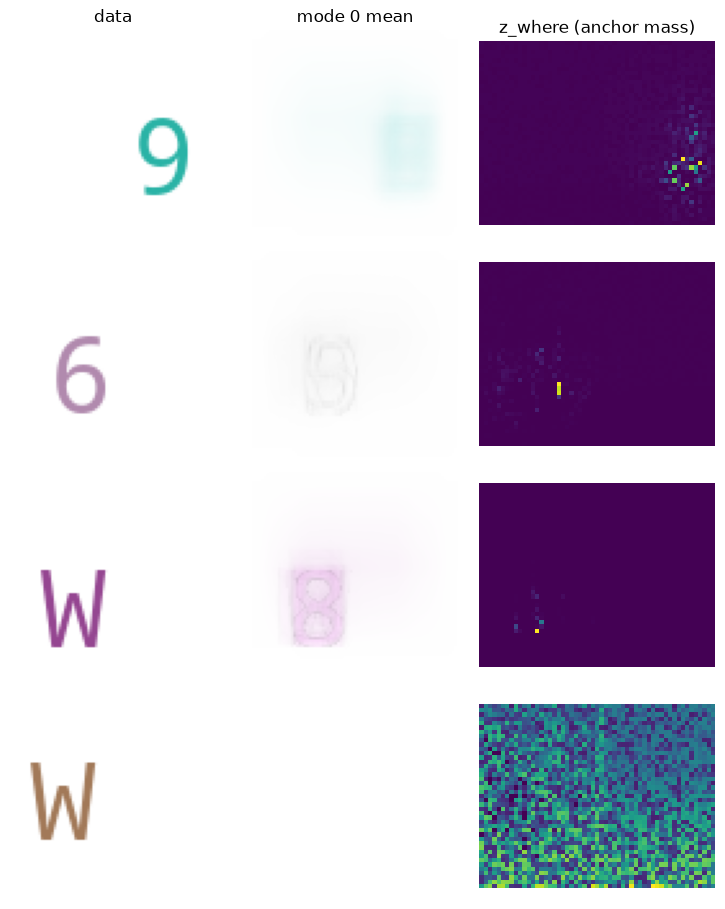

mode mse       0.00811
white baseline 0.00976
max mark mass  0.608   (1.0 would be an anchor committed to a single glyph)


In [8]:
def reconstruct(result, model, images, k, key=jax.random.key(4)):
    latents = {name: result.modes[name][k] for name in result.structure.continuous}
    trace = handlers.trace(
        handlers.substitute(handlers.seed(model, key), data=latents)
    ).get_trace(images)
    return np.asarray(trace["obs"]["fn"].mean)


def best_mode(result):
    good = usable_modes(result)
    return int(jnp.argmax(jnp.where(good, result.log_joint, -jnp.inf)))


k = best_mode(result)
mean = reconstruct(result, model, images, k)
anchor_h = result.modes["z_mark"].shape[-3]
anchor_w = result.modes["z_mark"].shape[-2]

fig, axes = plt.subplots(BATCH, 3, figsize=(7.5, 2.3 * BATCH))
for i in range(BATCH):
    axes[i, 0].imshow(np.asarray(images[i]))
    axes[i, 1].imshow(mean[i])
    axes[i, 2].imshow(np.asarray(result.modes["z_where"][k, i]).reshape(anchor_h, anchor_w))
    for ax in axes[i]:
        ax.axis("off")
axes[0, 0].set_title("data")
axes[0, 1].set_title(f"mode {k} mean")
axes[0, 2].set_title("z_where (anchor mass)")
plt.tight_layout()
plt.show()

print(f"mode mse       {((mean - np.asarray(images)) ** 2).mean():.5f}")
print(f"white baseline {((np.asarray(images) - 1.0) ** 2).mean():.5f}")
print(f"max mark mass  {float(result.modes['z_mark'][k].max()):.3f}"
      f"   (1.0 would be an anchor committed to a single glyph)")

The per-image hue comes out right, the `z_where` mass concentrates near the character, and
the MSE is clearly better than predicting blank white. But the mean image is a faint blob
rather than a glyph: `max mark mass` stays far below 1, so no anchor commits to an identity
and each pixel's mixture averages many sprites. MAP inference here localizes and colors; it
does not identify.

## Stage 3: bounds on log Z, and learning through them

`log_weights` gives per-particle importance weights under the mixture proposal; `elbo` and
`iwae` are the Jensen and importance-weighted bounds built from them, differentiable in
`result.params` (the model's own `log_scale` and `count_concentration`, plus the proposal's
locations and scales).

In [9]:
log_w = result.log_weights(params, jax.random.key(1))
finite = jnp.isfinite(log_w)
weights = jax.nn.softmax(jnp.where(finite, log_w, -jnp.inf))
print("log_weights   ", np.asarray(log_w).round(1))
print("finite weights", f"{int(finite.sum())} of {log_w.shape[0]}")
print("ess           ", f"{float(1.0 / jnp.sum(weights ** 2)):.3f}")
print("elbo          ", float(result.elbo(params, jax.random.key(1))))
print("iwae          ", float(result.iwae(params, jax.random.key(1))))

log_weights    [-28021.4 -27405.4     -inf     -inf     -inf -27663.6     -inf -27858.2]
finite weights 4 of 8
ess            1.000
elbo           -inf
iwae           -27407.455078125


### Finding 3: `-inf` weights, and what they do to learning

Some proposal draws land off the model's support, giving `log_weights = -inf`. The mechanism
is float32 rather than conceptual: `z_where` is a Dirichlet over 2365 anchors, so once the
allocation concentrates -- which both the sparse prior and the likelihood push for -- the
smallest simplex coordinates underflow to exactly 0 under stick-breaking, and `log_prob`
reports out-of-support.

That has an asymmetric effect on the two bounds: `elbo` is a mean, so one `-inf` makes it
`-inf`; `iwae` is a log-sum-exp, so it survives. **But the gradient does not.** An `inf`
potential energy differentiates to `NaN`, and `NaN * 0` from the log-sum-exp's vanishing
weight poisons the whole gradient, so IWAE learning `NaN`s out as soon as a particle lands
off-support.

Things that do *not* fix it, all tested: `damping` from 1 to 1000 (narrower proposals still
straddle the boundary, and the bound degrades by an order of magnitude), more particles
(more finite weights, same `NaN` gradient), and interior concentrations
(`where=mark=1.0` -- and `concentration == 1` makes `(alpha - 1) * log 0` a `NaN` outright).

`jax_enable_x64` is the principled direction, since it moves the underflow from `exp(-40)`
out to `exp(-700)`, and the FWL docs recommend x64 independently. It is not free here: it
needs `ShapeDictionary.shapes` cast to float64 (`lax.conv_general_dilated` rejects mixed
dtypes), and an x64 attempt at this batch size was abandoned after 12 minutes at ~93 GB of
device memory without completing a single Find. Untested, therefore, rather than ruled out.

The loop below therefore takes the gradient only while it stays finite, and reports where it
stopped. Treat the resulting parameters as a demonstration of the plumbing, not a fit.

stopped at step 3: non-finite IWAE gradient (Finding 3)
3 usable steps in 10.7s
log_scale            [-2.3115842] (sigma = 0.0991)
count_concentration  1.982076644897461


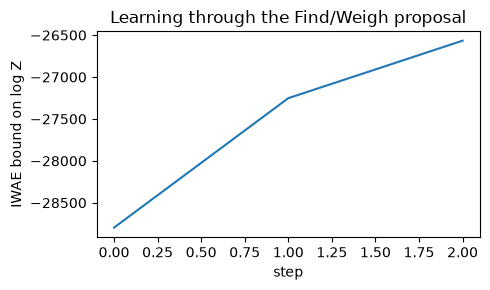

In [10]:
unconstrained = result.unconstrain(params)
optimizer = optax.adam(3e-3)
opt_state = optimizer.init(unconstrained)


def loss_fn(u, key):
    return -result.iwae(result.constrain(u), key)


@jax.jit
def step(u, opt_state, key):
    loss, grads = jax.value_and_grad(loss_fn)(u, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    finite = jnp.all(jnp.asarray([jnp.all(jnp.isfinite(g))
                                  for g in jax.tree.leaves(grads)]))
    return optax.apply_updates(u, updates), opt_state, loss, finite


key = jax.random.key(10)
history = []
t0 = time.time()
for i in range(50):
    key, subkey = jax.random.split(key)
    candidate, candidate_state, loss, finite = step(unconstrained, opt_state, subkey)
    if not bool(finite) or not np.isfinite(float(loss)):
        print(f"stopped at step {i}: non-finite IWAE gradient (Finding 3)")
        break
    unconstrained, opt_state = candidate, candidate_state
    history.append(float(loss))
print(f"{len(history)} usable steps in {time.time() - t0:.1f}s")

if history:
    learned = result.constrain(unconstrained)
    print("log_scale           ", np.asarray(learned["log_scale"]),
          f"(sigma = {float(jnp.exp(learned['log_scale'][0])):.4f})")
    print("count_concentration ", float(learned["count_concentration"]))
    plt.figure(figsize=(5, 3))
    plt.plot(-np.asarray(history))
    plt.xlabel("step")
    plt.ylabel("IWAE bound on log Z")
    plt.title("Learning through the Find/Weigh proposal")
    plt.tight_layout()
    plt.show()

## What would make this method fit this model

Three changes, in the order they block each other.

**Bound the density (Finding 2).** Find needs a joint density with an interior mode, so the
sparsity cannot come from sub-unit Dirichlet concentrations. Sparsity carried by the
intensity field with concentrations above 1, or genuinely discrete firing indicators, would
both work -- and discrete indicators would additionally give the max-product half of Find
something to eliminate, which is the part of the procedure that is exact.

**Keep the simplex off the float32 boundary (Finding 3).** A 2365-way `z_where` simplex is
the wrong shape for stick-breaking in single precision. Either run in x64 (after casting the
glyph dictionary), or reparameterize the allocation so that per-anchor mass does not require
2365 coordinates summing to 1 -- e.g. independent Gammas whose sum is the rate, which is the
same marked-process semantics without the simplex.

**Factorize the likelihood (Finding 1).** Min-sum only earns its keep with more than one
clique, and while the whole image is a single `obs` site every latent lands in one clique no
matter how the latents are parameterized. The change with the right shape is to tile the
image, giving each tile its own `obs` factor and its own `z_where`/`z_mark` sites, with tiles
chosen so an anchor's glyph support lies inside its own tile (at `kh=38, kw=26` on 80x80,
that is a 2x3 tiling). Global `color` and `z_rate` then sit in the root clique with one leaf
clique per tile: a bushy, height-1 tree. Height is what matters, because nested elimination
costs `(solver steps) ** height` -- `FWLOptions.max_nesting_depth` defaults to 4 for that
reason, so a chain of per-column cliques (height ~27 at stride 1) is hopeless where a
height-1 star is cheap.